In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, ConfusionMatrixDisplay)
import warnings # control warning messages because these libraries give lots of warnings which are not actually the error and only end up cluttering our notebook.

# now to ignore the warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/application_train_features.csv")
print(df.shape)
df.head()

(307511, 131)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,HAS_HOUSING_DATA,HAS_BUREAU_INQUIRY_DATA,EXT_SOURCE_1_WAS_MISSING,EXT_SOURCE_3_WAS_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.0,False,25.920548,1.745205,2.007889,0.121978,1,1,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,False,45.931507,3.254795,4.790750,0.132217,1,1,0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,False,52.180822,0.616438,2.000000,0.100000,0,1,1,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,False,52.068493,8.326027,2.316167,0.219900,0,0,1,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,False,54.608219,8.323288,4.222222,0.179963,0,1,1,1


In [7]:
X = df.drop(columns="TARGET")
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (246008, 130)
Testing set : (61503, 130)


In [8]:
numerical_features = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape :", X_test_processed.shape)

Processed Training Shape: (246008, 254)
Processed Testing Shape : (61503, 254)


In [15]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg.fit(X_train_processed, y_train)

y_pred_log = log_reg.predict(X_test_processed)
y_prob_log = log_reg.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_log))

Logistic Regression Results:
Accuracy : 0.6878688844446612
Precision: 0.16120738906874882
Recall   : 0.6819738167170192
F1 Score : 0.2607724594709076
ROC AUC  : 0.7503992983250364


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest Results:
Accuracy : 0.9192722306228964
Precision: 0.5
Recall   : 0.0014098690835850957
F1 Score : 0.0028118096003213497
ROC AUC  : 0.7200418013291029


In [17]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train_processed, y_train)

y_pred_lgbm = lgbm_model.predict(X_test_processed)
y_prob_lgbm = lgbm_model.predict_proba(X_test_processed)[:, 1]

print("LightGBM Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lgbm))

LightGBM Results:
Accuracy : 0.7048761849015495
Precision: 0.16889312977099236
Recall   : 0.6773413897280967
F1 Score : 0.27037022148972945
ROC AUC  : 0.7594975504537279


In [28]:
import xgboost
import catboost
print(xgboost.__version__)
print(catboost.__version__)

3.2.0
1.2.10


In [29]:
from xgboost import XGBClassifier

# XGBoost uses scale_pos_weight instead of class_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("XGBoost Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results:
Accuracy : 0.7341430499325237
Precision: 0.17479721238432538
Recall   : 0.6163141993957704
F1 Score : 0.2723510302167238
ROC AUC  : 0.7459161172674389


In [30]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=100,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)

cat_model.fit(X_train_processed, y_train)

y_pred_cat = cat_model.predict(X_test_processed)
y_prob_cat = cat_model.predict_proba(X_test_processed)[:, 1]

print("CatBoost Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall   :", recall_score(y_test, y_pred_cat))
print("F1 Score :", f1_score(y_test, y_pred_cat))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_cat))

CatBoost Results:
Accuracy : 0.713363575760532
Precision: 0.16951983298538623
Recall   : 0.6541792547834844
F1 Score : 0.2692642487046632
ROC AUC  : 0.7506398551935073


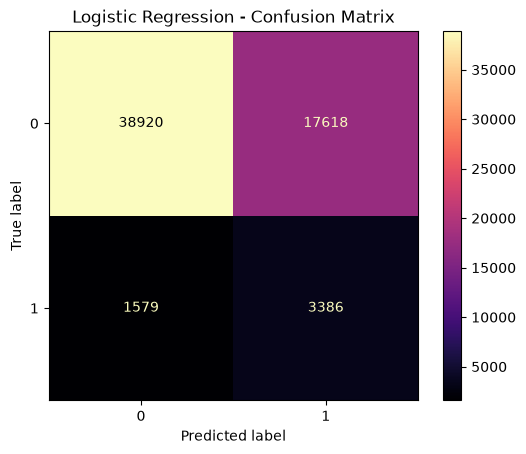

In [24]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap="magma")
disp.ax_.set_title("Logistic Regression - Confusion Matrix")
plt.show()

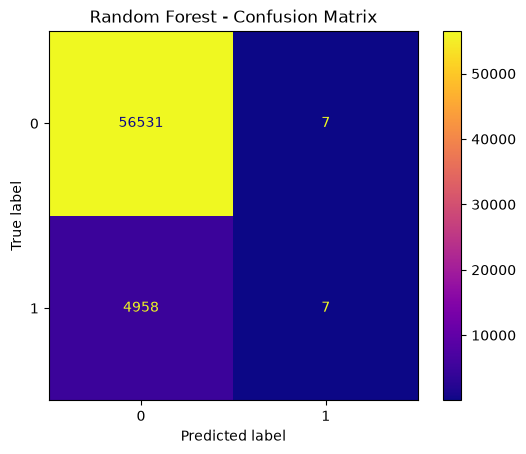

In [25]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="plasma")
disp.ax_.set_title("Random Forest - Confusion Matrix")
plt.show()

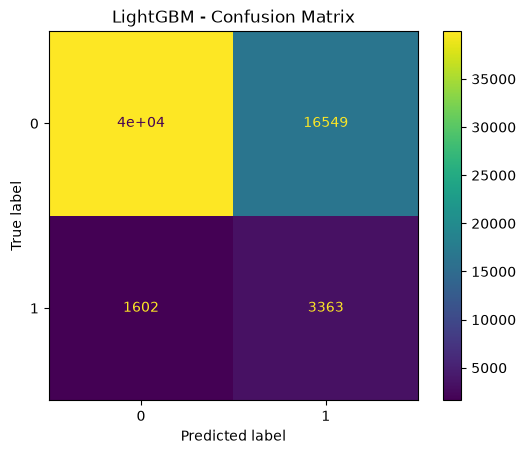

In [27]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, cmap="viridis")
disp.ax_.set_title("LightGBM - Confusion Matrix")
plt.show()


Text(0.5, 1.0, 'XGBoost - Confusion Matrix')

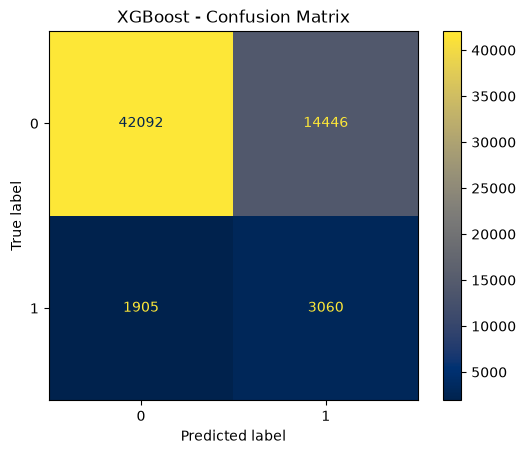

In [31]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap="cividis")
disp.ax_.set_title("XGBoost - Confusion Matrix")

Text(0.5, 1.0, 'CatBoost - Confusion Matrix')

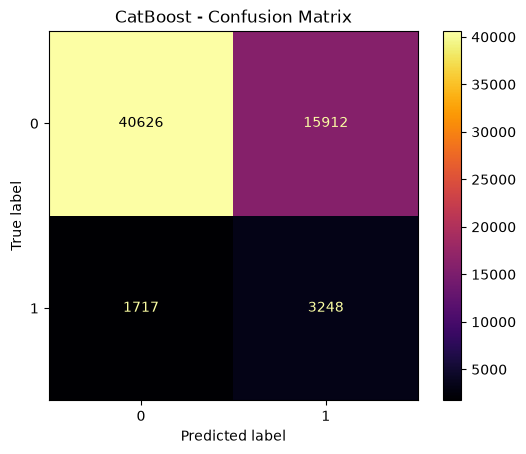

In [32]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cat, cmap="inferno")
disp.ax_.set_title("CatBoost - Confusion Matrix")

## Model Selection

Five machine learning models were evaluated for loan default prediction: Logistic Regression, Random Forest, LightGBM, XGBoost, and CatBoost.

Among all models, **LightGBM** demonstrated the best overall performance. It achieved the highest ROC-AUC score (0.759), indicating the strongest ability to distinguish between defaulters and non-defaulters. It also maintained a high recall (0.677) while achieving a competitive F1 score (0.270), providing a good balance between identifying default cases and minimizing false predictions.

Although Logistic Regression achieved the highest recall (0.682), its lower precision and ROC-AUC indicate weaker overall predictive performance compared to LightGBM.

XGBoost achieved the highest F1 score (0.272) and the highest precision among the balanced models, but its recall (0.616) was lower than LightGBM, making it slightly less effective at identifying default cases.

CatBoost produced stable results with balanced performance but did not outperform LightGBM on the primary evaluation metrics.

Random Forest achieved the highest accuracy (0.919); however, its recall (0.001) was extremely low, indicating that it failed to identify most loan defaulters. This highlights that accuracy alone is not an appropriate evaluation metric for highly imbalanced datasets.

Based on the experimental results, **LightGBM was selected as the best-performing model** for subsequent analysis and future deployment due to its superior balance of recall, F1 score, and ROC-AUC.|

In [35]:
import os
os.makedirs("models", exist_ok=True)

In [36]:
import joblib

joblib.dump(lgbm_model, "models/lightgbm_model.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

['models/preprocessor.pkl']